In [1]:
for model in models:
    for rxn in model.reactions:
        print(rxn.id, rxn.reaction, rxn.lower_bound, rxn.upper_bound)
    
    model.optimize()
    print(model.summary())

NameError: name 'models' is not defined

In [1]:
import gifba
# rel_abund = [0.5, 0.5]
# rel_abund = "equal"
rel_abund = [0.2, 0.8]
# rel_abund = [0.5, 0.5]
iters = 100
step_size=1

# load models and media:
sim = "5a"
models, media = gifba.utils.load_simple_models(sim)
# initialize community
community = gifba.gifbaObject(models, media, rel_abund=rel_abund)

# run iterations
# media_flux, org_flux = community.run_gifba(iters=iters, method="pfba", early_stop=True, v=True)
media_flux, org_flux = community.run_gifba(iters=iters, method="pfba", threshold=True, v=True, debug=True)



Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01
Read LP format model from file /tmp/tmpqbfpwkxc.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros
Read LP format model from file /tmp/tmpj59slbhw.lp
Reading time = 0.00 seconds
: 6 rows, 14 columns, 24 nonzeros

Iteration: 0
#############################################
Run Info
Objective value (model 0): 0.0
Objective value (model 1): 0.0

env fluxes (mmol/(gT/hr)):
EX_Bio(e)    0.0
Ex_B(e)      0.0
Ex_A(e)      0.0
Name: (0, 0), dtype: float64

org fluxes (mmol/(gT/hr)):
       EX_Bio(e)  Ex_B(e)  Ex_A(e)
Model                             
0            0.0      0.0      0.0
1            0.0      0.0      0.0
#############################################


Iteration: 1
#############################################
Run Info
Objective value (model 0): 0.0
Objective value (model 1): 0.0

env fluxes (mmol/(gT/hr)):
EX_Bio(e)    0.0
Ex_B(e)     

In [2]:
print(community.org_final[community.env_fluxes.columns])
print(community.org_final[community.env_fluxes.columns].sum())

community.summarize()

       exchangeBio  Ex_B  Ex_A
Model                         
0              5.0   5.0  -5.0
1              5.0  -5.0  -5.0
exchangeBio    1.000000e+01
Ex_B           3.907985e-14
Ex_A          -1.000000e+01
dtype: float64


Metabolite,Exchange,Flux,C-Number,C-Flux
A_e,Ex_A,10.0,0,0.00%
Metabolite,Exchange,Flux,C-Number,C-Flux
biomass2e,exchangeBio,1.000000e+01,0,0.00%
B_e,Ex_B,3.907985e-14,0,0.00%
Metabolite,Exchange,Flux,C-Number,C-Flux
A_e,Ex_A,5.0,0,0.00%
Metabolite,Exchange,Flux,C-Number,C-Flux
biomass2e,exchangeBio,5.0,0,0.00%
B_e,Ex_B,5.0,0,0.00%
Metabolite,Exchange,Flux,C-Number,C-Flux


(0,)
(0,)
(0,)
(0,)
Empty DataFrame
Columns: [OC, X, rerun_ct, iter]
Index: []


/tmp/ipykernel_15291/3781058212.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()
/tmp/ipykernel_15291/3781058212.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()
/tmp/ipykernel_15291/3781058212.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[2].legend()


Text(0.5, 1.0, 'Overconsumption vs X')

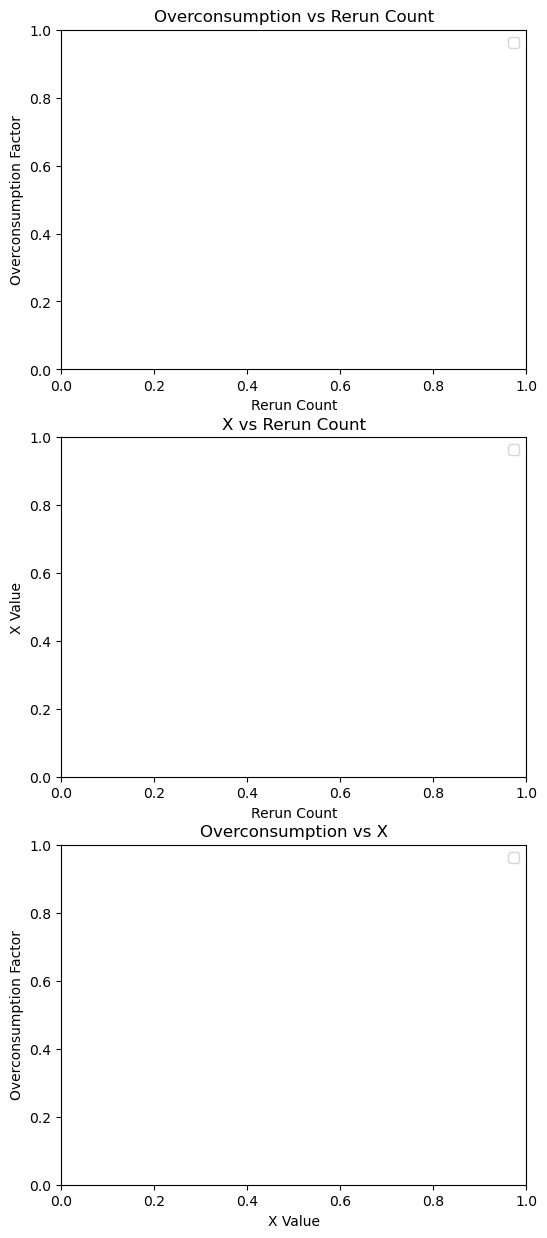

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
print(np.array(community.OC_list).shape)
print(np.array(community.X_list).shape)
print(np.array(community.rerun_list).shape)
print(np.array(community.iter_list).shape)
OC_meta = pd.DataFrame(np.array([community.OC_list, community.X_list, community.rerun_list, community.iter_list]).T, columns=["OC", "X", "rerun_ct", "iter"])
print(OC_meta)
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(6,15))
for iter in OC_meta.iter.unique():
    iter_df = OC_meta[OC_meta.iter == iter]
    ax[0].plot(iter_df.rerun_ct, iter_df.OC, label=f"iter {iter}")
    ax[1].plot(iter_df.rerun_ct, iter_df.X, label=f"iter {iter}")
    ax[2].plot(iter_df.X, iter_df.OC, label=f"iter {iter}")


ax[0].legend()
ax[1].legend()
ax[2].legend()

ax[0].set_xlabel("Rerun Count")
ax[0].set_ylabel("Overconsumption Factor")
ax[0].set_title("Overconsumption vs Rerun Count")
ax[1].set_xlabel("Rerun Count")
ax[1].set_ylabel("X Value")
ax[1].set_title("X vs Rerun Count")
ax[2].set_xlabel("X Value")
ax[2].set_ylabel("Overconsumption Factor")
ax[2].set_title("Overconsumption vs X")


In [3]:
community.env_fluxes

,Ex_C,Ex_B,Ex_A
Iteration,,,
0,0.0,0.0,10.0
1,0.0,0.0,10.0
2,0.0,0.0,10.0
3,0.0,0.0,10.0
4,0.0,0.0,10.0
...,...,...,...
96,0.0,0.0,10.0
97,0.0,0.0,10.0
98,0.0,0.0,10.0


In [2]:
community.org_fluxes


,,T_A,T_Bio,T_B,Ex_C,BiomassFromA,exchangeBio,Ex_B,T_C,Ex_A,BiomassFromC,BiomassFromAB,BiomassFromB
Model,Iteration,,,,,,,,,,,,
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
for idx, model in enumerate(M):
    print(idx, f" of {len(M)} models")
    for rxn in model.reactions:
        print(rxn.id, "  ", end="")
        for met in rxn.metabolites:
            if rxn.metabolites[met] < 0:
                print(f"{-rxn.metabolites[met]}*{met.id}", end="    ")

        print("->   ", end="")
        for met in rxn.metabolites:
            if rxn.metabolites[met] > 0:
                print(f" {abs(rxn.metabolites[met])}*{met.id}", end="    ")
        print()
    print()

0  of 2 models
12PPDt   1.0*12ppd_S[e]    ->    1.0*12ppd_S[c]    
23DHMPO   1.0*23dhmp[c]    1.0*nadp[c]    ->    1.0*3h3mop[c]     1.0*h[c]     1.0*nadph[c]    
23PDE2   1.0*23cump[c]    1.0*h2o[c]    ->    1.0*3ump[c]     1.0*h[c]    
23PDE4   1.0*23ccmp[c]    1.0*h2o[c]    ->    1.0*3cmp[c]     1.0*h[c]    
23PDE7   1.0*23camp[c]    1.0*h2o[c]    ->    1.0*3amp[c]     1.0*h[c]    
23PDE9   1.0*23cgmp[c]    1.0*h2o[c]    ->    1.0*3gmp[c]     1.0*h[c]    
2AHBUTI   1.0*2ahbut[c]    ->    1.0*3h3mop[c]    
3CARLPDH   1.0*HC01435[c]    1.0*lpam[c]    ->    1.0*HC00695[c]     1.0*thmpp[c]    
3MOBS   1.0*3c3hmp[c]    1.0*coa[c]    1.0*h[c]    ->    1.0*3mob[c]     1.0*accoa[c]     1.0*h2o[c]    
3OAR100   1.0*3odecACP[c]    1.0*h[c]    1.0*nadph[c]    ->    1.0*3hdecACP[c]     1.0*nadp[c]    
3OAR10M11   1.0*10m3oundecACP[c]    1.0*h[c]    1.0*nadph[c]    ->    1.0*10m3hundecACP[c]     1.0*nadp[c]    
3OAR10M12   1.0*10m3oddcaACP[c]    1.0*h[c]    1.0*nadph[c]    ->    1.0*10m3hddcaACP

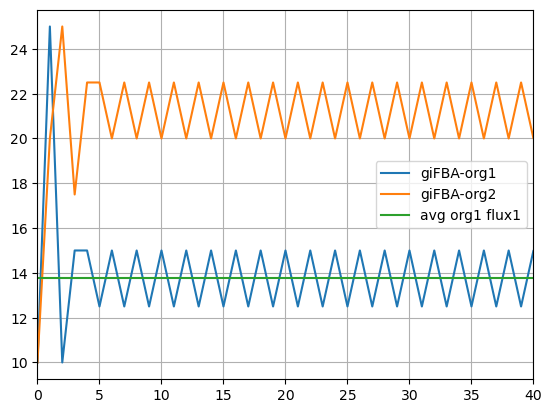

In [5]:
import matplotlib.pyplot as plt
import numpy as np
plt.plot(community.org_fluxes.loc[0,"exchangeBio"], label='giFBA-org1')
plt.plot(community.org_fluxes.loc[1,"exchangeBio"], label='giFBA-org2')
# plt.plot(community.org_fluxes.loc[2,"exchangeBio"], label='giFBA-org3')
plt.plot([org_flux.loc[0, "exchangeBio"]] *community.iters, label='avg org1 flux1')
plt.legend()
plt.grid()
plt.xlim(0, 40)



plt.show()




In [ ]:
community.env_fluxes

,exchangeBio,Ex_A,Ex_C
Iteration,,,
0,0.0,10.0,0.000000
1,10.0,10.0,10.000000
2,10.0,10.0,8.000000
3,10.0,10.0,8.333333
4,10.0,10.0,8.275862
...,...,...,...
96,10.0,10.0,8.284271
97,10.0,10.0,8.284271
98,10.0,10.0,8.284271


In [ ]:
community.org_fluxes

,,exchangeBio,T_A,T_Biomass,Ex_C,Biomass,Ex_A,T_C
Model,Iteration,,,,,,,
0,0,10.000000,10.000000,10.000000,10.000000,10.000000,-10.000000,10.000000
1,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0,1,8.000000,8.000000,8.000000,8.000000,8.000000,-8.000000,8.000000
1,1,2.000000,2.000000,2.000000,-2.000000,2.000000,-2.000000,2.000000
0,2,8.333333,8.333333,8.333333,8.333333,8.333333,-8.333333,8.333333
...,...,...,...,...,...,...,...,...
1,97,1.715729,1.715729,1.715729,-1.715729,1.715729,-1.715729,1.715729
0,98,8.284271,8.284271,8.284271,8.284271,8.284271,-8.284271,8.284271
1,98,1.715729,1.715729,1.715729,-1.715729,1.715729,-1.715729,1.715729


In [15]:
community.summarize()

Metabolite,Exchange,Flux,C-Number,C-Flux
biomass2e,exchangeBio,10.0,0,0.00%
C_e,Ex_C,8.0,0,0.00%
Metabolite,Exchange,Flux,C-Number,C-Flux
A_e,Ex_A,2.0,0,0.00%
Metabolite,Exchange,Flux,C-Number,C-Flux
biomass2e,exchangeBio,2.0,0,0.00%
C_e,Ex_C,2.0,0,0.00%
Metabolite,Exchange,Flux,C-Number,C-Flux
A_e,Ex_A,8.0,0,0.00%
C_e,Ex_C,8.0,0,0.00%


# Real Models


In [1]:
import cobra as cb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

m1 = cb.io.load_matlab_model('AGORA2_Models/Bifidobacterium_longum_infantis_ATCC_15697.mat')
m2 = cb.io.load_matlab_model('AGORA2_Models/Eubacterium_hallii_DSM_3353.mat')

M = [m1, m2]

# Define Media

# AGORA Format
media = {
	'EX_o2(e)': 0, #aerobic/anaerobic
	'EX_h2o(e)': -1000,
	'EX_pi(e)': -1000,
	'EX_fe2(e)': -1000,
	'EX_fe3(e)': -1000,
	'EX_zn2(e)': -1000,
	'EX_so4(e)': -1000,
	'EX_cu2(e)': -1000,
	'EX_k(e)': -1000,
	'EX_mg2(e)': -1000,
	'EX_mn2(e)': -1000,
	'EX_cd2(e)': -1000,
	'EX_cl(e)': -1000,
	'EX_ca2(e)': -1000,
	'EX_cobalt2(e)': -1000,
	'EX_glc_D(e)': -10,
	'EX_nh4(e)': -20,

	'EX_ribflv(e)': -1000,
	'EX_pnto_R(e)': -1000,
	'EX_nac(e)': -1000,
	'EX_his_L(e)': -1000,
	'EX_asn_L(e)': -1000,
	'EX_glycys(e)': -1000,

	'EX_lys_L(e)': -1000,
	'EX_ala_L(e)': -1000,
	'EX_met_L(e)': -1000,
	'EX_leu_L(e)': -1000,
	'EX_hxan(e)': -1000,    
    'EX_glyglu(e)': -1000
	# 'EX_ser_L(e)': -1 #-1
}


Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


In [1]:
import cobra as cb
import pandas as pd

# load models
CD_path = "AGORA2_Models/Clostridium_difficile_R20291.mat"
CD = cb.io.load_matlab_model(CD_path)

CH_path = "AGORA2_Models/Clostridium_hiranonis_TO_931_DSM_13275.mat"
CH = cb.io.load_matlab_model(CH_path)

BT_path = "AGORA2_Models/Bacteroides_thetaiotaomicron_3731.mat"
BT = cb.io.load_matlab_model(BT_path)

EL_path = "AGORA2_Models/Eggerthella_lenta_DSM_11767.mat"
EL = cb.io.load_matlab_model(EL_path)

M = [CD, CH, BT, EL]
media = "AGORA2_Models/euro_diet.tsv"
media = pd.read_csv(media, sep="\t", header=0, index_col=0).to_dict()
media = media["Flux Value"]
euro_media = {ex.replace("[e]", "(e)"): -flux for ex, flux in media.items()}

#example glucose minimal media
min_med_ids_ex = ['EX_glc_D(e)','EX_so4(e)','EX_nh4(e)','EX_pi(e)','EX_cys_L(e)',
			'EX_mn2(e)','EX_cl(e)','EX_ca2(e)','EX_mg2(e)','EX_cu2(e)',
			'EX_cobalt2(e)','EX_fe2(e)','EX_fe3(e)','EX_zn2(e)','EX_k(e)']
# Define medium uptake flux bounds
min_med_fluxes_ex = [-10,-100,-100,-100,-100,
					-100,-100,-100,-100,-100,-100,-100,-100,-100,-100]
min_media = dict(zip(min_med_ids_ex, min_med_fluxes_ex))


Set parameter Username
Set parameter LicenseID to value 2773321
Academic license - for non-commercial use only - expires 2027-02-01


No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e, p
No defined compartments in model model. Compartments will be deduced heuristically using regular expressions.
Using regular expression found the following compartments:c, e


In [2]:
import gifba
# rel_abund = [0.5, 0.5]
rel_abund = "equal"
# rel_abund = [0.8, 0.2]
iters = 100
step_size=1



# initialize community
community = gifba.gifbaObject(M, media, rel_abund=rel_abund, OC_method="newton", method="pfba", OC_Rounding = 10)

# run iterations
# media_flux, org_flux = community.run_gifba(iters=iters, method="pfba", early_stop=True, v=True)
media_flux, org_flux = community.run_gifba(iters=iters, method="pfba", threshold=True, v=True)

Read LP format model from file /tmp/tmpszhx8i6l.lp
Reading time = 0.01 seconds
: 932 rows, 2064 columns, 8440 nonzeros
Read LP format model from file /tmp/tmp0f5blxi_.lp
Reading time = 0.01 seconds
: 980 rows, 2102 columns, 8980 nonzeros

Iteration: 0
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 1
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 2
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 3
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)

Iteration: 4
EX_glc_D(e) over-consumed by factor of 2.000000000000 (rerun count: 0)
Converged at iteration 4
Model is periodic and average of the last 1 iterations will be used for flux calculations.


In [5]:
summary = community.summarize()

edge, node = summary.to_cytoscape()
edge.to_csv("Ahalii_Binfantis_edges.csv")
node.to_csv("Ahalii_Binfantis_nodes.csv")

In [12]:
for col in community.org_fluxes.columns:
    if col.startswith("bio") or col.startswith("biomass"):
        print(col)

biomass525
biomass536


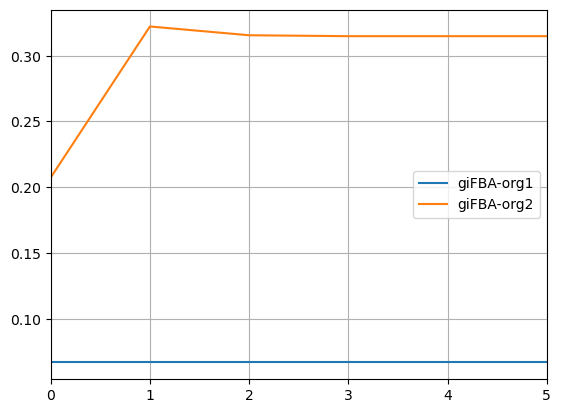

In [5]:
import matplotlib.pyplot as plt
import numpy as np
ex = "EX_biomass(e)"
plt.plot(community.org_fluxes.loc[0,ex], label='giFBA-org1')

plt.plot(community.org_fluxes.loc[1,ex], label='giFBA-org2')
# plt.plot(community.org_fluxes.loc[2,ex], label='giFBA-org3')
# plt.plot(community.org_fluxes.loc[3,ex], label='giFBA-org4')
# plt.plot([org_flux.loc[0, ex]] *community.iters, label='avg org1 flux1')
# plt.plot([org_flux.loc[1, ex]] *community.iters, label='avg org2 flux1')
plt.legend()
plt.grid()
plt.xlim(0, 5)



plt.show()


